# FINAL PROJECT

**Deliverables**:
  1. Your version of this notebook, where you create the required agents (complete all the associated tasks)

  2. After training your agents, you might want to save those learnt values. This can be a dictionary with the `optimal policy`, or `Q-values`. If an approximate method was used, you can provide the `final weights`, etc.

  3. A short report (no more than 10 pages), where you explain your methodology, chosen parameters, visualisations of the learning process (how rewards increase over time, or how loss functions decrease).

  4. Upload to `Faser` a .zip file of all the deliverables (including th optimal Q-values/weights/policies)

**Evaluation**: Your projects will be evaluated primarily on the development of the agents, not necessarily in their performance. Being said that, better performance will lead in general to better marks.

## 0. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gymnasium as gym
from IPython.display import Image, display
import imageio

from collections import defaultdict
from tqdm import tqdm
from optuna.trial import FixedTrial

from src.logger import LogManager
from src.utils import save_policy, plot_learning_curve, plot_smoothed_learning_curve, q_stats
from src.optimization import param_opt_pipeline, get_params

In [2]:
manager = LogManager()

main_log = manager.get_logger("Main", "main.log")

In [3]:
env = gym.make("Acrobot-v1", render_mode = "rgb_array")
state = env.reset()

main_log.info("--- New Session Started ---")
main_log.info(f"Environment: Acrobot-v1")
main_log.info(f"Initial State: {state}")
main_log.info(f"State Space: {env.observation_space}")
main_log.info(f"Action Space: {env.action_space}")

2026-04-18 08:05:30 | INFO    | --- New Session Started ---
2026-04-18 08:05:30 | INFO    | Environment: Acrobot-v1
2026-04-18 08:05:30 | INFO    | Initial State: (array([ 0.9962425 , -0.08660752,  0.99873894,  0.05020513, -0.05214284,
       -0.01433886], dtype=float32), {})
2026-04-18 08:05:30 | INFO    | State Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
2026-04-18 08:05:30 | INFO    | Action Space: Discrete(3)


[ACROBOT ENVIRONMENT](https://gymnasium.farama.org/environments/classic_control/acrobot/)

Below is the default discretisation (for the states. Actions are already discrete). If you consider that a different one, could lead to better performance, feel free to modify it, and indicate this in your report.

In [4]:
ANGLE_BINS = 10
VEL_BINS = 12

LOW = np.array([-np.pi, -np.pi, -6, -10])
HIGH = np.array([ np.pi,  np.pi,  6,  10])
BINS = np.array([ANGLE_BINS, ANGLE_BINS, VEL_BINS, VEL_BINS])

def transform_state(obs):
    cos1, sin1, cos2, sin2, w1, w2 = obs
    
    theta1 = np.arctan2(sin1, cos1)
    theta2 = np.arctan2(sin2, cos2)
    
    return np.array([theta1, theta2, w1, w2])

def discretise(obs):
    state = transform_state(obs)
    
    ratios = (state - LOW) / (HIGH - LOW)
    ratios = np.clip(ratios, 0, 1)
    
    discrete = (ratios * (BINS - 1)).astype(int)
    return tuple(discrete)

In [5]:
main_log.info(f"Discretization Bins: {BINS}")

2026-04-18 08:05:30 | INFO    | Discretization Bins: [10 10 12 12]


## 1. Notebook Utilities

In [6]:
def select_action(policy, state, mode="greedy", epsilon=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if isinstance(policy[state], np.ndarray):  # Q-table
        if mode == "greedy":
            return np.argmax(policy[state])
        elif mode == "epsilon_greedy":
            if rng.random() < epsilon:
                return rng.integers(len(policy[state]))
            return np.argmax(policy[state])

    else:  # probability policy (REINFORCE)
        probs = policy[state]
        if mode == "greedy":
            return np.argmax(probs)
        elif mode == "stochastic":
            return rng.choice(len(probs), p=probs)
        elif mode == "epsilon_greedy":
            if rng.random() < epsilon:
                return rng.integers(len(probs))
            return np.argmax(probs)

In [ ]:
def evaluate_policy(policy, n_episodes=20, mode="greedy", seed=42):
    env = gym.make("Acrobot-v1")

    rewards = []
    steps = []

    for ep in range(n_episodes):
        rng = np.random.default_rng(seed + ep)

        obs, _ = env.reset()
        state = discretise(obs)

        done = False
        total_reward = 0
        t = 0

        while not done:
            action = select_action(policy, state, mode = mode, rng = rng)
            obs, reward, term, trunc, _ = env.step(action)

            state = discretise(obs)
            total_reward += reward
            t += 1
            done = term or trunc

        rewards.append(total_reward)
        steps.append(t)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_steps": np.mean(steps),
        "success_rate": np.mean(np.array(steps) < 500)
    }

In [8]:
def record_episode(policy, filename, mode="greedy"):
    env = gym.make("Acrobot-v1", render_mode="rgb_array")
    frames = []

    obs, _ = env.reset()
    state = discretise(obs)

    done = False

    while not done:
        frames.append(env.render())
        action = select_action(policy, state, mode=mode)
        obs, reward, term, trunc, _ = env.step(action)

        state = discretise(obs)
        done = term or trunc

    imageio.mimsave(filename, frames, fps=50)

In [ ]:
def run_experiment(algorithm_func, name, params):
    main_log.info(f"Starting Experiment: {name}")
    
    params["seed"] = 42
    params["n_episodes"] = 2000

    main_log.info(f"Hyperparameters: {params}")

    # ---------------- TRAIN ----------------
    model, rewards = algorithm_func(env, params=params)

    main_log.info(f"{name} Training Completed")

    # ---------------- SAVE ----------------
    save_policy(model, name)

    # ---------------- EVALUATE ----------------
    eval_greedy = evaluate_policy(model, mode="greedy")
    eval_stochastic = eval_policy(model, mode="stochastic")

    main_log.info(f"{name} Evaluation (Greedy): {eval_greedy}")

    print("\n=== EVALUATION ===")
    print("Greedy:", eval_greedy)
    print("Stochastic:", eval_stochastic)

    # ---------------- PLOTS ----------------
    plot_learning_curve(rewards, name)
    plot_smoothed_learning_curve(rewards, name)

    # ---------------- RECORD ----------------
    record_episode(model, f"results/{name}_greedy.gif", mode="greedy")
    record_episode(model, f"results/{name}_stochastic.gif", mode="stochastic")

    return model, rewards, {
        "greedy": eval_greedy,
        "stochastic": eval_stochastic
    }

## 2. Algorithms

### SARSA

In [10]:
def alg_SARSA(env, params):
    """
    SARSA implementation.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    for ep in tqdm(range(n_episodes), desc = "Training SARSA"):
        obs, _ = env.reset()
        state = discretise(obs)
        action = select_action(
            policy = Q, 
            state = state, 
            mode = "epsilon_greedy", 
            epsilon = epsilon, 
            rng = rng
        )

        total_reward = 0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)
            
            next_action = select_action(
                policy = Q, 
                state = next_state, 
                mode = "epsilon_greedy", 
                epsilon = epsilon, 
                rng = rng
            )

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### Q-Learning [UG: 30 /  PGT: 20] marks


In here you will need to implement a version of Q-Learning, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of Q-learning
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [11]:
def alg_Q(env, params: dict):
    """
    Q-Learning implementation using a centralized parameter dictionary.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training Q-Learning", leave = False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        total_reward = 0
        done = False

        while not done:
            action = select_action(
                policy = Q,
                state = state,
                mode = "epsilon_greedy",
                epsilon = epsilon,
                rng = rng
            )

            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)

            # Off policy
        
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            state = next_state
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### n-step SARSA [UG: 35 / PGT: 30] marks


In here you will need to implement a version of n-step SARSA, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of n-step SARSA
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [12]:
def alg_nStep_SARSA(env, params):
    """
    n-Step SARSA implementation using a centralized parameter dictionary.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]
    n = params["n"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    # Initialize pi to be epsilon-greedy with respect to Q,
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training n-Step SARSA", leave = False)

    for ep in iterator:

        obs, _ = env.reset()
        state = discretise(obs)
        action = select_action(
            policy = Q,
            state = state,
            mode = "epsilon_greedy",
            epsilon = epsilon,
            rng = rng
        )

        states = [state]
        actions = [action]
        rewards = [0.0]

        total_reward = 0

        T = np.inf
        tau = 0
        t = 0

        while tau < T - 1:
            if t < T:
                # Take action A_t, observe R_{t+1}, S_{t+1}
                next_obs, reward, term, trunc, _ = env.step(actions[t])
                next_state = discretise(next_obs)
                
                rewards.append(reward)
                states.append(next_state)

                total_reward += reward

                if term or trunc:
                    T = t + 1
                else:
                    # Select and store next action A_{t+1}
                    next_action = select_action(
                        policy = Q,
                        state = next_state,
                        mode = "epsilon_greedy",
                        epsilon = epsilon,
                        rng = rng
                    )
                    actions.append(next_action)
            
            # tau is the time whose estimate is being updated
            tau = t - n + 1

            if tau >= 0:
                # Calculate the n-step return G
                # G = sum_{i=tau+1}^{min(tau+n, T)} gamma^(i-tau-1) * R_i
                G = 0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                
                # Add the bootstrapped value of the state at the end of the window
                if tau + n < T:
                    S_n = states[tau + n]
                    A_n = actions[tau + n]
                    G += (gamma ** n) * Q[S_n][A_n]
                
                S_tau = states[tau]
                A_tau = actions[tau]
                Q[S_tau][A_tau] += alpha * (G - Q[S_tau][A_tau])

            t += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### REINFORCE [UG: 35 / PGT: 30 ] marks


In here you will need to implement a version of REINFORCE, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of REINFORCE
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [13]:
def get_probs(h):
    exp_h = np.exp(h - np.max(h)) # Stability
    return exp_h / np.sum(exp_h)

In [ ]:
def alg_REINFORCE_B(env, params):
    """
    REINFORCE with baseline (state-value function).
    """

    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]

    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    gamma = params["gamma"]

    alpha_theta = params["alpha_theta"]
    alpha_w = params["alpha_w"]

    # Policy (logits) and baseline
    h = defaultdict(lambda: np.zeros(n_actions))
    v = defaultdict(float)

    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training REINFORCE-B", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        ep_states = []
        ep_actions = []
        ep_rewards = []

        done = False

        # --- Generate trajectory ---
        while not done:
            probs = get_probs(h[state])
            action = rng.choice(n_actions, p=probs)

            ep_states.append(state)
            ep_actions.append(action)

            obs, reward, term, trunc, _ = env.step(action)
            state = discretise(obs)

            ep_rewards.append(reward)
            done = term or trunc

        rewards_history.append(np.sum(ep_rewards))

        # --- Compute returns ---
        T = len(ep_rewards)
        returns = np.zeros(T)

        G = 0.0
        for t in reversed(range(T)):
            G = ep_rewards[t] + gamma * G
            returns[t] = G

        # Normalize returns - only when there's meaningful variance
        if returns.std() > 1e-3:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        else:
            returns = returns - returns.mean()  # just center, don't scale

        # --- Update ---
        for t in range(T):
            s = ep_states[t]
            a = ep_actions[t]
            G_t = returns[t]

            # Baseline update
            delta = G_t - v[s]
            v[s] += alpha_w * delta

            # Policy gradient
            probs = get_probs(h[s])
            grad = -probs
            grad[a] += 1.0

            h[s] += alpha_theta * (gamma ** t) * delta * grad

    # Convert logits → policy
    policy = {s: get_probs(h_s) for s, h_s in h.items()}

    return policy, rewards_history

### SARSA($\lambda$) [PGT: 20 marks ]


In here you will need to implement a version of SARSA($\lambda$), test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of SARSA($\lambda$)
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [15]:
def alg_SARSA_Lambda(env, params):
    """
    SARSA(lambda) with replacing traces.
    """

    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]

    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n

    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]

    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]
    lam = params["lambda"]

    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training SARSA(λ)", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        E = defaultdict(lambda: np.zeros(n_actions))

        action = select_action(
            policy=Q,
            state=state,
            mode="epsilon_greedy",
            epsilon=epsilon,
            rng=rng
        )

        total_reward = 0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)

            next_action = select_action(
                policy=Q,
                state=next_state,
                mode="epsilon_greedy",
                epsilon=epsilon,
                rng=rng
            )

            # --- TD target ---
            if term or trunc:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state][next_action]

            delta = td_target - Q[state][action]

            # --- Replacing trace ---
            E[state][action] = 1.0

            # --- Update ---
            for s in list(E.keys()):
                Q[s] += alpha * delta * E[s]
                E[s] *= gamma * lam

                if np.all(E[s] < 1e-6):
                    del E[s]

            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

## 3. Experiments

### Baseline

**Default parameters**: I defined the following parameters as the default ones, they will allow you to run things in a reasonable time for testing. However, for properly training your agents, you will need longer time.

**Remark:** the visualisation is just a guidance of performance, the real test of performance is the cumulative rewards.

In [16]:
# --- HYPERPARAMETERS ---
# These parameters are SARSA / Q-learning specific. 

SARSA_PARAMS = {
    # Problem parameters: <- Fixed parameters to the given problem
    "n_episodes": 1000,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.05,

    # Config parameters: <- Display and Robustness testing
    "seed": 42,
    "show_progress": False,

    # Algorithm parameters: <- Parameters optimized for robust algorithms
    "alpha": 0.15,
    "epsilon_decay": 0.99,
}

2026-04-18 02:19:20 | INFO    | Starting Experiment: SARSA
2026-04-18 02:19:20 | INFO    | Hyperparameters: {'n_episodes': 1000, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_min': 0.05, 'seed': 42, 'show_progress': False, 'alpha': 0.15, 'epsilon_decay': 0.99}


Training SARSA: 100%|██████████| 1000/1000 [00:43<00:00, 22.93it/s]

2026-04-18 02:20:03 | INFO    | SARSA Training Completed
2026-04-18 02:20:04 | INFO    | Model checkpoint saved: models/SARSA.pkl


2026-04-18 02:20:04 | INFO    | SARSA Evaluation (Greedy): {'mean_reward': np.float64(-223.45), 'std_reward': np.float64(74.93829128022603), 'mean_steps': np.float64(224.45), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-223.45), 'std_reward': np.float64(74.93829128022603), 'mean_steps': np.float64(224.45), 'success_rate': np.float64(1.0)}


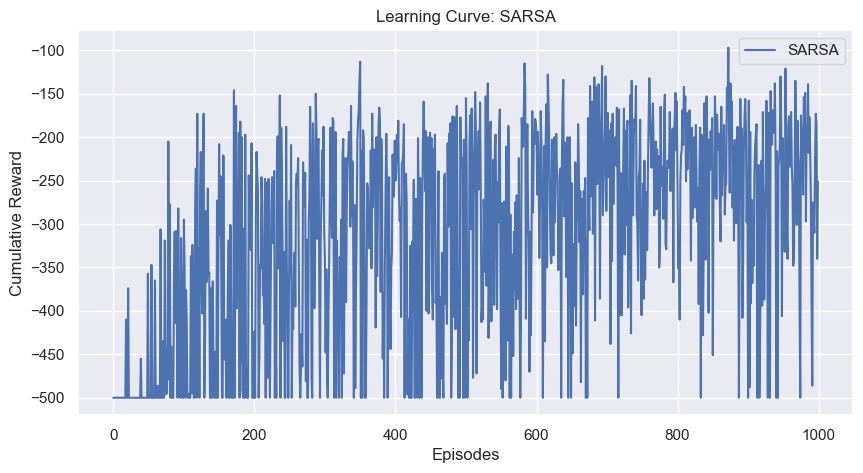

2026-04-18 02:20:05 | INFO    | Plot created in notebook.


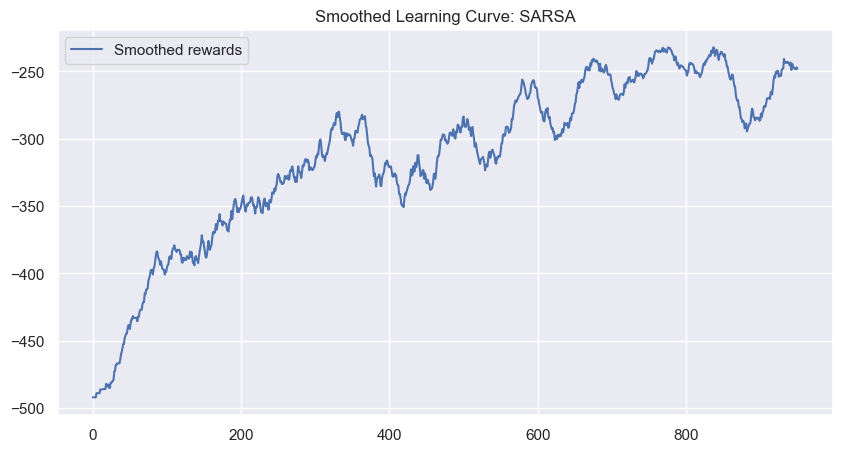

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\rcorr\anaconda3\envs\reinforced\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists



Final Summary:
{'greedy': {'mean_reward': np.float64(-223.45), 'std_reward': np.float64(74.93829128022603), 'mean_steps': np.float64(224.45), 'success_rate': np.float64(1.0)}}


In [17]:
model, rewards, evals = run_experiment(alg_SARSA, "SARSA", params = SARSA_PARAMS)

print("\nFinal Summary:")
print(evals)

### Hyperparameter Optimization Pipeline

#### Q-learning

In [18]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_Q.__name__}")
best_trial = param_opt_pipeline(alg_Q, n_trials = 64)

best_trial.params

2026-04-18 02:20:10 | INFO    | Starting Optuna Hyperparameter Search: alg_Q


Optimizing alg_Q: 100%|██████████| 64/64 [1:10:52<00:00, 66.44s/it] 


{'alpha': 0.3644045873803047, 'epsilon_decay': 0.903637661037472}

2026-04-18 03:31:03 | INFO    | Starting Experiment: Q-learning
2026-04-18 03:31:03 | INFO    | Hyperparameters: {'n_episodes': 1000, 'gamma': 0.99, 'show_progress': False, 'alpha': 0.3644045873803047, 'epsilon': 1.0, 'epsilon_decay': 0.903637661037472, 'epsilon_min': 0.05, 'seed': 42}
2026-04-18 03:31:39 | INFO    | Q-learning Training Completed
2026-04-18 03:31:39 | INFO    | Model checkpoint saved: models/Q-learning.pkl
2026-04-18 03:31:40 | INFO    | Q-learning Evaluation (Greedy): {'mean_reward': np.float64(-241.55), 'std_reward': np.float64(63.12644057762167), 'mean_steps': np.float64(242.55), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-241.55), 'std_reward': np.float64(63.12644057762167), 'mean_steps': np.float64(242.55), 'success_rate': np.float64(1.0)}


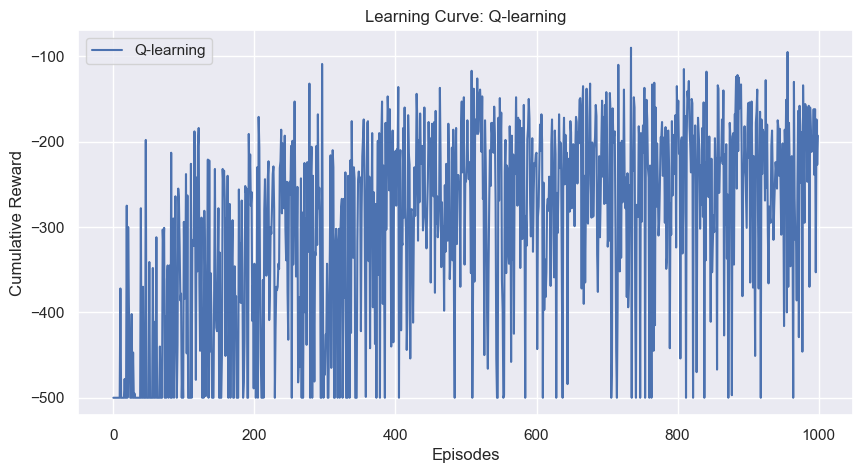

2026-04-18 03:31:40 | INFO    | Plot created in notebook.


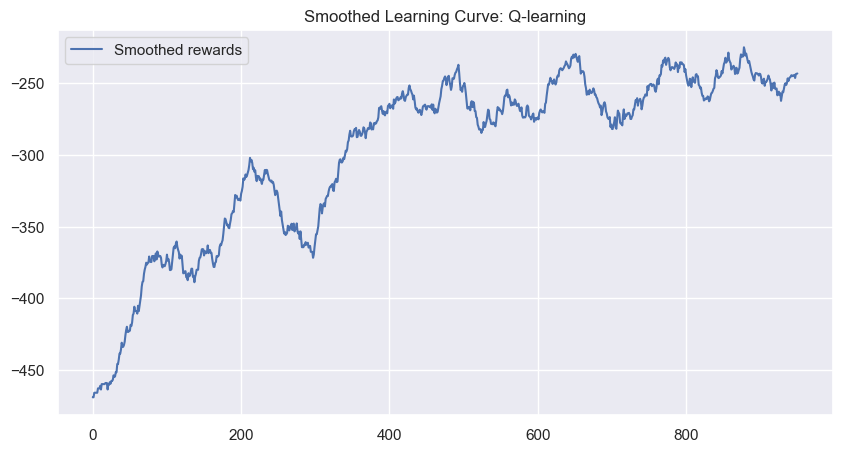


Final Summary:
{'greedy': {'mean_reward': np.float64(-241.55), 'std_reward': np.float64(63.12644057762167), 'mean_steps': np.float64(242.55), 'success_rate': np.float64(1.0)}}


In [19]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_Q")

model, rewards, evals = run_experiment(alg_Q, "Q-learning", params = final_params)

print("\nFinal Summary:")
print(evals)

In [20]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

Q mean: -6.446, Q std: 6.266


In [21]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.2975)

#### n-step SARSA

In [22]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_nStep_SARSA.__name__}")
best_trial = param_opt_pipeline(alg_nStep_SARSA, n_trials = 64)

best_trial.params

2026-04-18 03:31:47 | INFO    | Starting Optuna Hyperparameter Search: alg_nStep_SARSA


Optimizing alg_nStep_SARSA: 100%|██████████| 64/64 [44:14<00:00, 41.48s/it]  


{'alpha': 0.3601654602255309, 'epsilon_decay': 0.9438749924057246, 'n': 10}

2026-04-18 04:16:02 | INFO    | Starting Experiment: n-step SARSA
2026-04-18 04:16:02 | INFO    | Hyperparameters: {'n_episodes': 1000, 'gamma': 0.99, 'show_progress': False, 'alpha': 0.3601654602255309, 'epsilon': 1.0, 'epsilon_decay': 0.9438749924057246, 'epsilon_min': 0.05, 'n': 10, 'seed': 42}
2026-04-18 04:16:32 | INFO    | n-step SARSA Training Completed
2026-04-18 04:16:32 | INFO    | Model checkpoint saved: models/n-step SARSA.pkl
2026-04-18 04:16:32 | INFO    | n-step SARSA Evaluation (Greedy): {'mean_reward': np.float64(-176.8), 'std_reward': np.float64(38.06783419108579), 'mean_steps': np.float64(177.8), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-176.8), 'std_reward': np.float64(38.06783419108579), 'mean_steps': np.float64(177.8), 'success_rate': np.float64(1.0)}


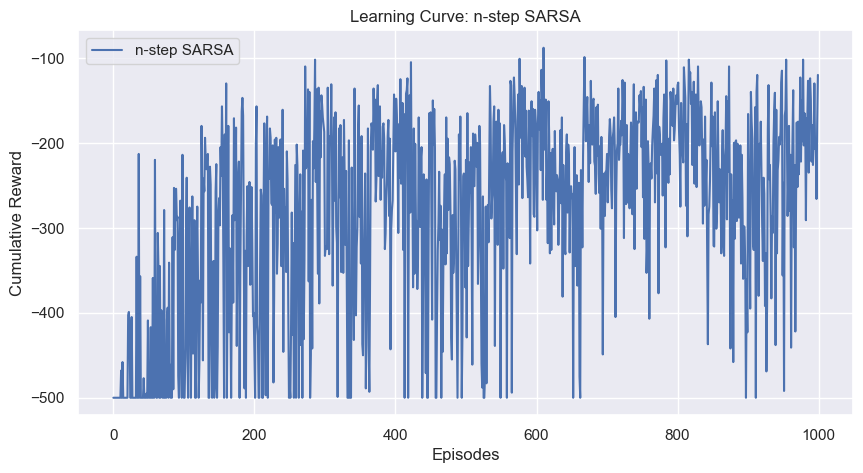

2026-04-18 04:16:33 | INFO    | Plot created in notebook.


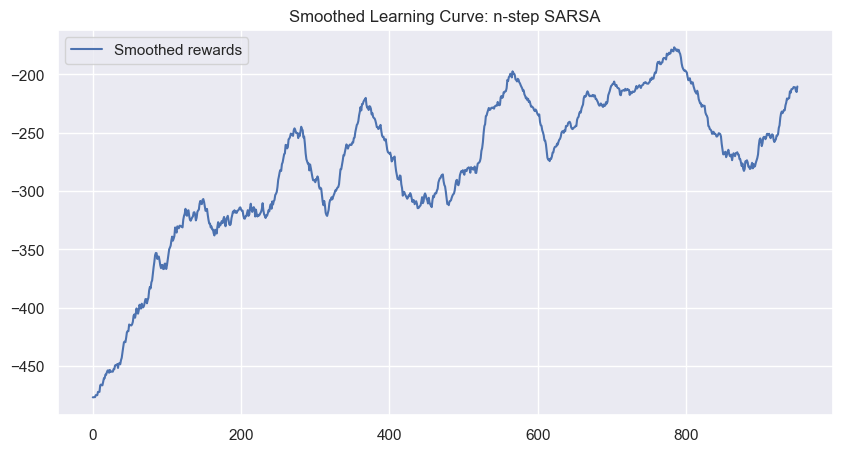


Final Summary:
{'greedy': {'mean_reward': np.float64(-176.8), 'std_reward': np.float64(38.06783419108579), 'mean_steps': np.float64(177.8), 'success_rate': np.float64(1.0)}}


In [23]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_nStep_SARSA")

model, rewards, evals = run_experiment(alg_nStep_SARSA, "n-step SARSA", params = final_params)

print("\nFinal Summary:")
print(evals)

In [24]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

Q mean: -27.365, Q std: 20.266


In [25]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.28520833333333334)

#### REINFORCE

In [ ]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_REINFORCE_B.__name__}")
best_trial = param_opt_pipeline(alg_REINFORCE_B, n_trials = 6)

best_trial.params

2026-04-18 04:16:37 | INFO    | Starting Optuna Hyperparameter Search: alg_REINFORCE_B


Optimizing alg_REINFORCE_B: 100%|██████████| 64/64 [1:32:04<00:00, 86.32s/it]  


{'alpha_theta': 0.00017423309111568402, 'alpha_w': 0.0034897098495363724}

2026-04-18 05:48:42 | INFO    | Starting Experiment: REINFORCE
2026-04-18 05:48:42 | INFO    | Hyperparameters: {'n_episodes': 1000, 'gamma': 0.99, 'show_progress': False, 'alpha_theta': 0.00017423309111568402, 'alpha_w': 0.0034897098495363724, 'seed': 42}
2026-04-18 05:50:05 | INFO    | REINFORCE Training Completed
2026-04-18 05:50:05 | INFO    | Model checkpoint saved: models/REINFORCE.pkl
2026-04-18 05:50:06 | INFO    | REINFORCE Evaluation (Greedy): {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}


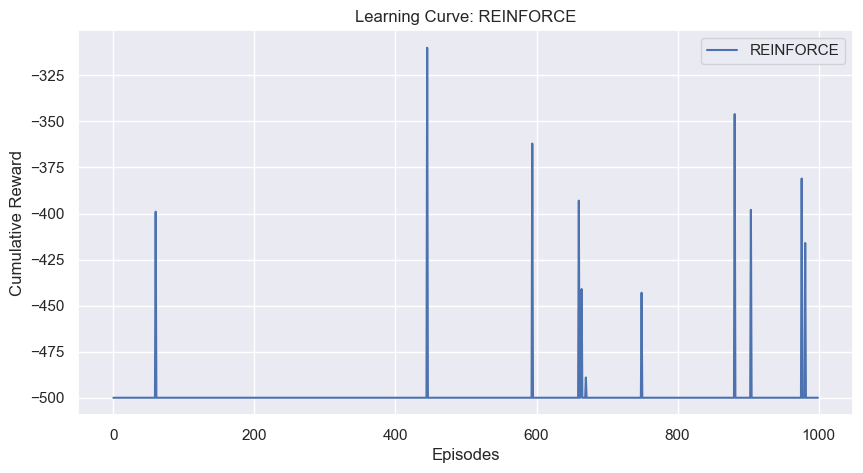

2026-04-18 05:50:06 | INFO    | Plot created in notebook.


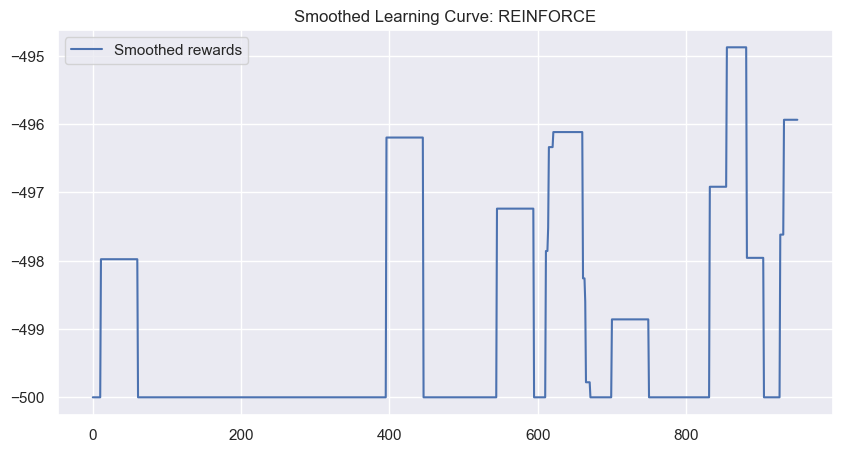


Final Summary:
{'greedy': {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}}


In [27]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_REINFORCE_B")

model, rewards, evals = run_experiment(alg_REINFORCE_B, "REINFORCE", params = final_params)

print("\nFinal Summary:")
print(evals)

In [28]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.1498611111111111)

#### SARSA($\lambda$)

In [ ]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_SARSA_Lambda.__name__}")
best_trial = param_opt_pipeline(alg_SARSA_Lambda, n_trials = 64)

best_trial.params

2026-04-18 08:05:50 | INFO    | Starting Optuna Hyperparameter Search: alg_SARSA_Lambda


Optimizing alg_SARSA_Lambda:   0%|          | 0/64 [00:00<?, ?it/s]

In [ ]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_SARSA_Lambda")

model, rewards, evals = run_experiment(alg_SARSA_Lambda, "SARSA Lambda", params = final_params)

print("\nFinal Summary:")
print(evals)

In [ ]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

In [ ]:
coverage = len(model.keys()) / np.prod(BINS)
coverage